In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os

In [2]:
df=pd.read_csv(r"Churn_Modelling.csv")



In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
EXT_NO=df[df.Exited==0].Tenure
EXT_YES=df[df.Exited==1].Tenure



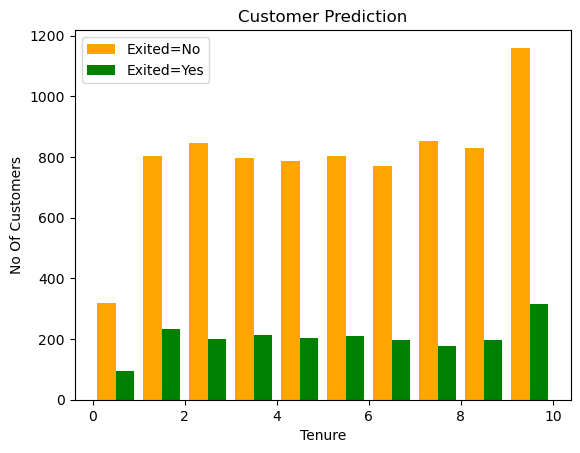

In [6]:

plt.xlabel('Tenure')
plt.ylabel('No Of Customers')
plt.title('Customer Prediction')
plt.hist([EXT_NO,EXT_YES],color=["orange","green"],label=['Exited=No','Exited=Yes'])
plt.legend()


In [7]:
df['Gender'].replace({'Female':1,'Male':0},inplace=True)
df


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,1,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,1,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,1,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,1,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,1,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,0,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,0,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,1,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,0,42,3,75075.31,2,1,0,92888.52,1


In [8]:
one_hot=pd.get_dummies(df['Geography'])
one_hot

,France,Germany,Spain
0,1,0,0
1,0,0,1
2,1,0,0
3,1,0,0
4,0,0,1
...,...,...,...
9995,1,0,0
9996,1,0,0
9997,1,0,0
9998,0,1,0


In [9]:
df=df.drop('Geography',axis=1)
df

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,1,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,1,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,1,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,1,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,1,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,0,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,0,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,1,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,0,42,3,75075.31,2,1,0,92888.52,1


In [10]:
df=df.join(one_hot)
df

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain
0,1,15634602,Hargrave,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,2,15647311,Hill,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,3,15619304,Onio,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,4,15701354,Boni,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,5,15737888,Mitchell,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,0,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,9997,15569892,Johnstone,516,0,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,9998,15584532,Liu,709,1,36,7,0.00,1,0,1,42085.58,1,1,0,0
9998,9999,15682355,Sabbatini,772,0,42,3,75075.31,2,1,0,92888.52,1,0,1,0


In [11]:
#independent variable
X=df.iloc[:,-1]
X

0       0
1       1
2       0
3       0
4       1
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: Spain, Length: 10000, dtype: uint8

In [12]:
#dependent variable
Y=df.iloc[:,:-1]
Y

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany
0,1,15634602,Hargrave,619,1,42,2,0.00,1,1,1,101348.88,1,1,0
1,2,15647311,Hill,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0
2,3,15619304,Onio,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0
3,4,15701354,Boni,699,1,39,1,0.00,2,0,0,93826.63,0,1,0
4,5,15737888,Mitchell,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,0,39,5,0.00,2,1,0,96270.64,0,1,0
9996,9997,15569892,Johnstone,516,0,35,10,57369.61,1,1,1,101699.77,0,1,0
9997,9998,15584532,Liu,709,1,36,7,0.00,1,0,1,42085.58,1,1,0
9998,9999,15682355,Sabbatini,772,0,42,3,75075.31,2,1,0,92888.52,1,0,1


In [32]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain
0,1,15634602,Hargrave,619,1,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,2,15647311,Hill,608,1,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,3,15619304,Onio,502,1,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,4,15701354,Boni,699,1,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,5,15737888,Mitchell,850,1,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [35]:
df.drop(['RowNumber','CustomerId','Surname'], axis=1, inplace=True)

In [13]:
from sklearn.model_selection import train_test_split

In [36]:
Y=df.iloc[:,-1]
X=df.iloc[:,:-1]
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X,Y, test_size=0.2 , random_state=5)


In [37]:
X_Train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany
7751,750,1,39,6,0.00,2,0,0,19264.33,0,0,0
4154,726,0,34,3,0.00,2,1,0,196288.46,0,1,0
3881,588,1,64,3,0.00,1,1,1,189703.65,0,1,0
9238,773,1,50,4,0.00,2,1,0,129372.94,0,1,0
5210,551,0,35,7,129717.30,2,0,0,86937.20,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3046,658,1,31,3,133003.03,1,0,1,146339.27,1,0,1
9917,635,0,53,8,117005.55,1,0,1,123646.57,1,0,1
4079,583,1,31,4,158978.79,1,1,0,12538.92,0,1,0
2254,679,0,36,6,147733.64,1,0,1,172501.38,0,1,0


In [40]:
X_Train.shape

(8000, 12)

In [41]:
X_Train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany
7751,750,1,39,6,0.0,2,0,0,19264.33,0,0,0
4154,726,0,34,3,0.0,2,1,0,196288.46,0,1,0
3881,588,1,64,3,0.0,1,1,1,189703.65,0,1,0
9238,773,1,50,4,0.0,2,1,0,129372.94,0,1,0
5210,551,0,35,7,129717.3,2,0,0,86937.20,0,1,0


In [17]:
Y_Train.shape

(8000, 15)

In [42]:
Y_Train.head()

7751    1
4154    0
3881    0
9238    0
5210    0
Name: Spain, dtype: uint8

In [43]:
X_Test.shape



(2000, 12)

In [44]:
Y_Test.shape


(2000,)

In [24]:
#pip install tensorflow

In [22]:
#neural network
import tensorflow as tf

from tensorflow import keras

In [45]:
model=keras.Sequential([
    keras.layers.Dense(30,activation='relu'),
    keras.layers.Dense(15,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')    
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
x_train=np.asarray(X_Train).astype(np.int)
y_train=np.asarray(Y_Train).astype(np.int)
model.fit(x_train,y_train,epochs=100)

Epoch 1/100


/var/folders/vw/hw8ks0qx7fd9x5j61l5qkzkh0000gq/T/ipykernel_65974/2291395954.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  x_train=np.asarray(X_Train).astype(np.int)
/var/folders/vw/hw8ks0qx7fd9x5j61l5qkzkh0000gq/T/ipykernel_65974/2291395954.py:9: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review you

250/250 [==============================] - 0s 478us/step - loss: 1613.3340 - accuracy: 0.6426
Epoch 2/100
250/250 [==============================] - 0s 451us/step - loss: 62.7062 - accuracy: 0.6270
Epoch 3/100
250/250 [==============================] - 0s 451us/step - loss: 46.8573 - accuracy: 0.6370
Epoch 4/100
250/250 [==============================] - 0s 450us/step - loss: 69.1236 - accuracy: 0.6308
Epoch 5/100
250/250 [==============================] - 0s 440us/step - loss: 55.8691 - accuracy: 0.6432
Epoch 6/100
250/250 [==============================] - 0s 444us/step - loss: 53.1160 - accuracy: 0.6454
Epoch 7/100
250/250 [==============================] - 0s 453us/step - loss: 58.2822 - accuracy: 0.6457
Epoch 8/100
250/250 [==============================] - 0s 445us/step - loss: 53.0096 - accuracy: 0.6444
Epoch 9/100
250/250 [==============================] - 0s 448us/step - loss: 49.2282 - accuracy: 0.6459
Epoch 10/100
250/250 [==============================] - 0s 459us/step - lo

In [47]:
predict=model.predict(X_Test)

63/63 [==============================] - 0s 405us/step


In [48]:
predict

array([[1.0000000e+00],
       [6.7896613e-12],
       [2.2219288e-06],
       ...,
       [1.0000000e+00],
       [9.9250114e-01],
       [1.5986632e-01]], dtype=float32)

In [78]:
classification=[]
for i in range(len(predict)):
    if predict[i]>0.5:
        classification.append(1)
    else:
        classification.append(0)

In [79]:
len(classification)

2000

In [80]:
pd.crosstab(Y_Test,classification)

col_0,0,1
Spain,,
0,850,643
1,111,396


In [85]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [84]:
confusion_matrix(Y_Test,classification)

array([[850, 643],
       [111, 396]])

In [87]:
print(classification_report(Y_Test,classification))

              precision    recall  f1-score   support

           0       0.88      0.57      0.69      1493
           1       0.38      0.78      0.51       507

    accuracy                           0.62      2000
   macro avg       0.63      0.68      0.60      2000
weighted avg       0.76      0.62      0.65      2000



In [70]:
len(predict)

2000

In [ ]:
df.dropna()

In [ ]:
df.dropna(inplace=True)